In [ ]:
from config import GlobalConfig
from helpers.Data import TokensPaths, load_queries
from transformers import AutoTokenizer

cfg =GlobalConfig()
queries_max_length = cfg.tokenize.queries_max_length
mention_start_special_token = cfg.tokenize.special_tokens_dict["mention_start"]
mention_end_special_token = cfg.tokenize.special_tokens_dict["mention_end"]
tokenizer = AutoTokenizer.from_pretrained(cfg.model.model_name, use_fast=True)
tokenizer.add_special_tokens(cfg.tokenize.special_tokens)


# train_queries = load_queries(
#             data_dir=cfg.paths.queries_raw_dir,
#             queries_max_length=queries_max_length,
#             special_token_start=mention_start_special_token ,
#             special_token_end=mention_end_special_token,
#             tokenizer=tokenizer)



c:\Users\antoi\Desktop\thesis\biosyn_faiss_prod\myenc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 691/691 [00:15<00:00, 45.03it/s]

annotation_skipped: 13


In [3]:
[tq[2] for tq in train_queries if 'autosomal recessive syndrome associated with a greatly' in  tq[2] ]

['[MS] Ataxia-telangiectasia [ME] (A-T) is an autosomal recessive syndrome associated with a greatly increased incidence of malignant neoplasms in homozygous affected individuals',
 'Ataxia-telangiectasia ( [MS] A-T [ME] ) is an autosomal recessive syndrome associated with a greatly increased incidence of malignant neoplasms in homozygous affected individuals',
 'Ataxia-telangiectasia (A-T) is an autosomal recessive syndrome associated with a greatly increased incidence of [MS] malignant neoplasms [ME] in homozygous affected individuals']

In [2]:
tokenizer.add_special_tokens({"additional_special_tokens": ["[MS]", "[ME]", "[S]", "[E]"]})


input_ids = tokenizer.encode('our results show frequent involvement of the p16 gene in [MS] familial melanoma [ME] and confirm the role of the CDK4 gene as a melanoma-predisposing gene')
tokens_with_special = tokenizer.convert_ids_to_tokens(input_ids)
tokens_with_special

['[CLS]',
 'our',
 'results',
 'show',
 'frequent',
 'involvement',
 'of',
 'the',
 'p',
 '##16',
 'gene',
 'in',
 '[MS]',
 'f',
 '##ami',
 '##lial',
 'me',
 '##lan',
 '##oma',
 '[ME]',
 'and',
 'confirm',
 'the',
 'role',
 'of',
 'the',
 'c',
 '##d',
 '##k',
 '##4',
 'gene',
 'as',
 'a',
 'me',
 '##lan',
 '##oma',
 '-',
 'pre',
 '##dis',
 '##po',
 '##sing',
 'gene',
 '[SEP]']

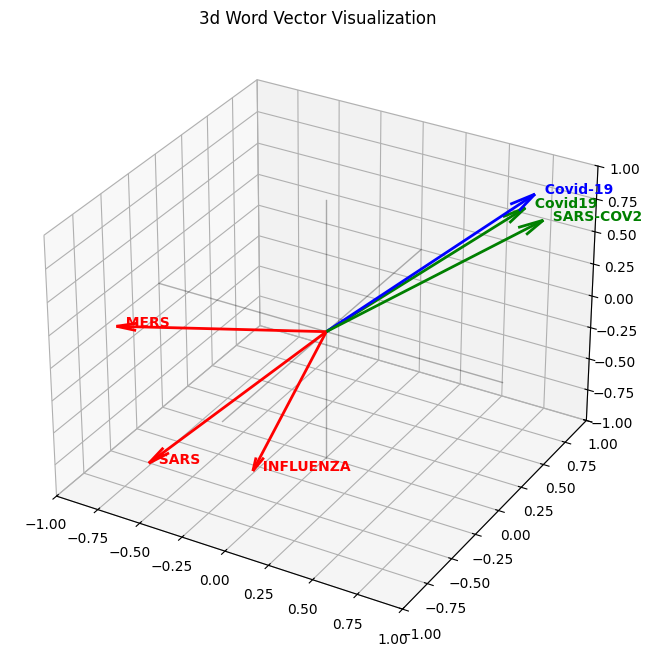

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup the words and their corresponding colors
words = ["Covid-19", "Covid19", "SARS-COV2", "MERS", "SARS", "INFLUENZA"]
# Colors: 1st Blue, 2nd-3rd Green, 4th-6th Red
colors = ['blue', 'green', 'green', 'red', 'red', 'red']
coords = np.array([
    [0.8, 0.7, 0.9],  # Blue (Reference)
    [0.7, 0.8, 0.7],  # Green 1 (Near Blue)
    [0.9, 0.6, 0.8],  # Green 2 (Near Blue)
    [-0.8, -0.7, 0.2], # Red 1 (Far)
    [-0.5, -0.9, -0.6],# Red 2 (Far)
    [-0.2, -0.4, -0.9] # Red 3 (Far)
])
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Plotting
for i in range(len(words)):
    # Plot the vector from (0,0,0) to the coordinate
    ax.quiver(0, 0, 0, coords[i, 0], coords[i, 1], coords[i, 2],
              color=colors[i], arrow_length_ratio=0.1, linewidth=2)
    
    # Label at the tip of the vector
    ax.text(coords[i, 0], coords[i, 1], coords[i, 2], 
            f"  {words[i]}", color=colors[i], fontsize=10, fontweight='bold')

# 4. Styling the "World"
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

# Adding a dashed line for the axes to make depth clearer
ax.plot([-1, 1], [0, 0], [0, 0], color='black', alpha=0.3, lw=1)
ax.plot([0, 0], [-1, 1], [0, 0], color='black', alpha=0.3, lw=1)
ax.plot([0, 0], [0, 0], [-1, 1], color='black', alpha=0.3, lw=1)

ax.set_title("3d Word Vector Visualization")
plt.show()


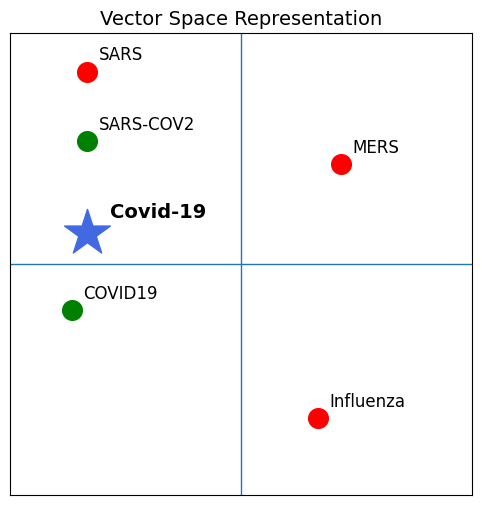

In [50]:
import matplotlib.pyplot as plt
def gen(green_points, red_points, blue_star):
    # --- Define points in vector space ---


    # --- Create figure ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Grid and axes
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.4)

    # Draw axis lines through origin
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    # --- Plot central star ---
    ax.scatter(*blue_star, s=1200, marker="*", color="royalblue", zorder=3)
    ax.text(
        blue_star[0] + 0.3,
        blue_star[1] + 0.2,
        "Covid-19",
        fontsize=14,
        weight="bold"
    )

    # --- Plot green points ---
    for label, (x, y) in green_points.items():
        ax.scatter(x, y, s=200, color="green", zorder=3)
        ax.text(x + 0.15, y + 0.15, label, fontsize=12)

    # --- Plot red points ---
    for label, (x, y) in red_points.items():
        ax.scatter(x, y, s=200, color="red", zorder=3)
        ax.text(x + 0.15, y + 0.15, label, fontsize=12)

    # Clean up frame
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Vector Space Representation", fontsize=14)
    return plt
blue_star = (-2, .4)

green_points = {
    "SARS-COV2": (-2, 1.6),
    "COVID19": (-2.2, -0.6),
}

red_points = {
    "SARS": (-2, 2.5),
    "MERS": (1.3, 1.3),
    "Influenza": (1, -2),
}
pl = gen(green_points, red_points , blue_star)
pl.show()
